# **FA23-bai-064**

# ANN LAB 03: Perceptron Classifier & Weight Initialization Strategies


In [1]:
# Setup: Dependencies installation & Perceptron Class Implementation from scratch
!pip install -q numpy pandas matplotlib seaborn scikit-learn

import numpy as np

class Perceptron:
    """
    Perceptron Classifier from scratch using NumPy.
    Supports zero, random, gaussian, xavier, he, and orthogonal weight initialization.
    """
    def __init__(self, learning_rate=0.01, max_epochs=100, init_method='zero', random_state=42):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.init_method = init_method
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.errors_ = []
        self.converged_epoch_ = None

    def _initialize_weights(self, n_features):
        rng = np.random.RandomState(self.random_state)
        n_in = n_features
        n_out = 1

        if self.init_method in ('zero', 'default'):
            self.weights = np.zeros(n_features)
            self.bias = 0.0
        elif self.init_method == 'random':
            self.weights = rng.uniform(-0.01, 0.01, size=n_features)
            self.bias = 0.0
        elif self.init_method == 'gaussian':
            self.weights = rng.normal(loc=0.0, scale=0.01, size=n_features)
            self.bias = 0.0
        elif self.init_method == 'xavier':
            # Xavier/Glorot Normal: std = sqrt(2 / (n_in + n_out))
            std = np.sqrt(2.0 / (n_in + n_out))
            self.weights = rng.normal(loc=0.0, scale=std, size=n_features)
            self.bias = 0.0
        elif self.init_method == 'he':
            # He/Kaiming Normal: std = sqrt(2 / n_in)
            std = np.sqrt(2.0 / n_in)
            self.weights = rng.normal(loc=0.0, scale=std, size=n_features)
            self.bias = 0.0
        elif self.init_method == 'orthogonal':
            # Orthogonal initialization: QR decomposition of random gaussian matrix
            H = rng.randn(n_features, max(1, n_features))
            Q, _ = np.linalg.qr(H)
            self.weights = Q[:, 0]
            self.bias = 0.0
        else:
            raise ValueError(f"Unknown initialization method: {self.init_method}")

    def net_input(self, X):
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._initialize_weights(n_features)
        self.errors_ = []
        self.converged_epoch_ = self.max_epochs

        for epoch in range(1, self.max_epochs + 1):
            epoch_errors = 0
            for xi, target in zip(X, y):
                prediction = 1 if (np.dot(xi, self.weights) + self.bias) >= 0.0 else 0
                update = self.learning_rate * (target - prediction)
                if update != 0.0:
                    self.weights += update * xi
                    self.bias += update
                    epoch_errors += 1
            self.errors_.append(epoch_errors)
            if epoch_errors == 0 and self.converged_epoch_ == self.max_epochs:
                self.converged_epoch_ = epoch
                break
        return self

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print('Perceptron class ready.')


Perceptron class ready.


## Lab Task 1: Dataset Loading and Visualization

1. Select and load a suitable binary-classification dataset from Kaggle or the UCI Machine Learning Repository.
2. Perform basic data inspection, including dataset shape, features, target variable, and missing values.
3. Visualize the dataset using appropriate plots to understand the distribution of the classes.
4. Split the dataset into training and testing sets and prepare the features for model training.


=== Dataset Inspection ===
Dataset Shape: (569, 31)
Selected Features: ['mean radius', 'mean texture']
Target Variable Classes: ['malignant' 'benign'] -> [0 1]
Missing Values in Selected Features:
mean radius     0
mean texture    0
dtype: int64
Class Distribution:
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64


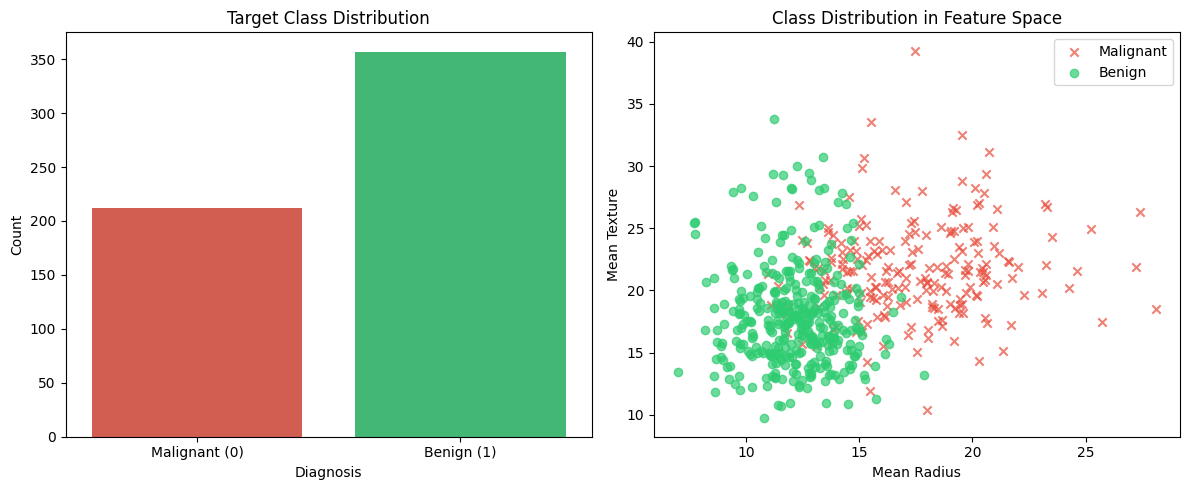

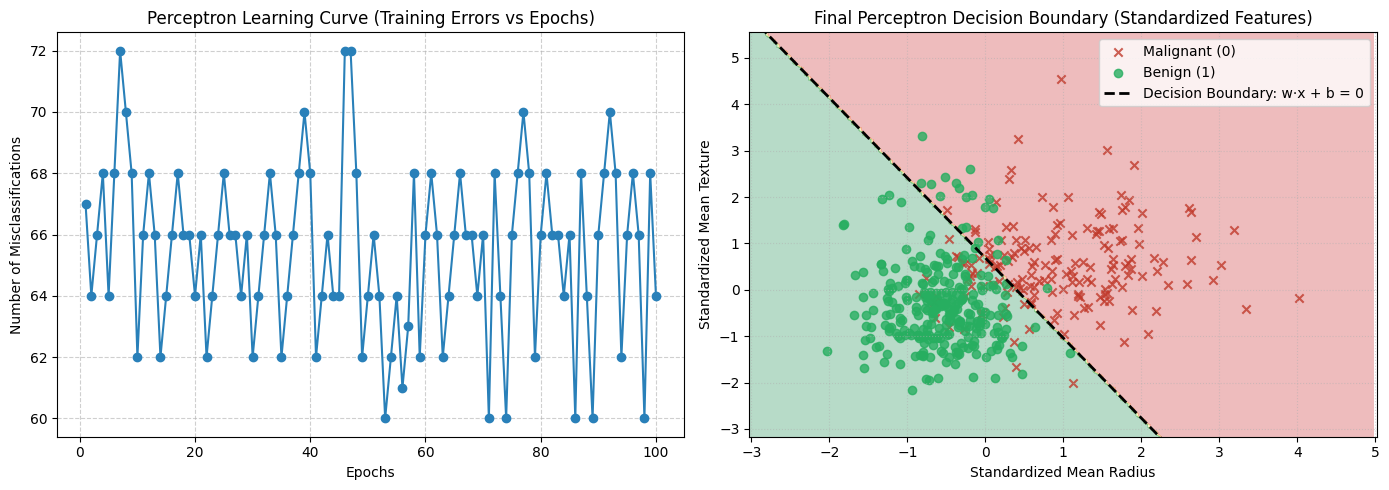

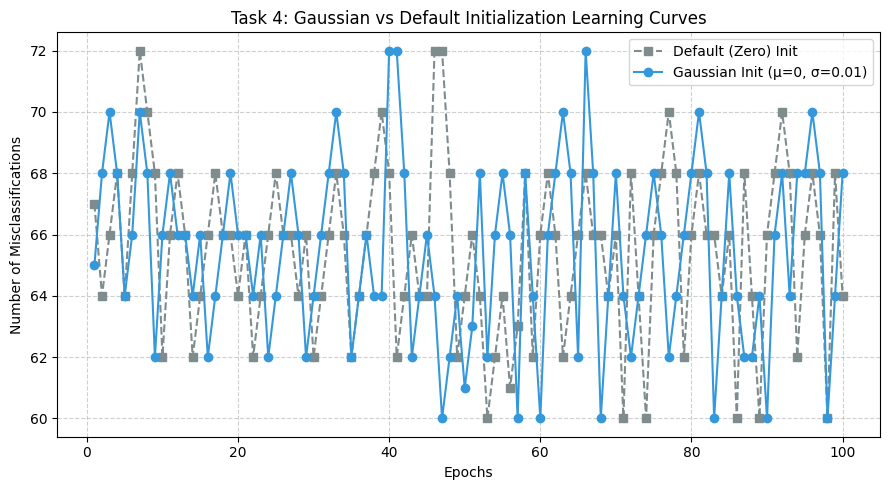

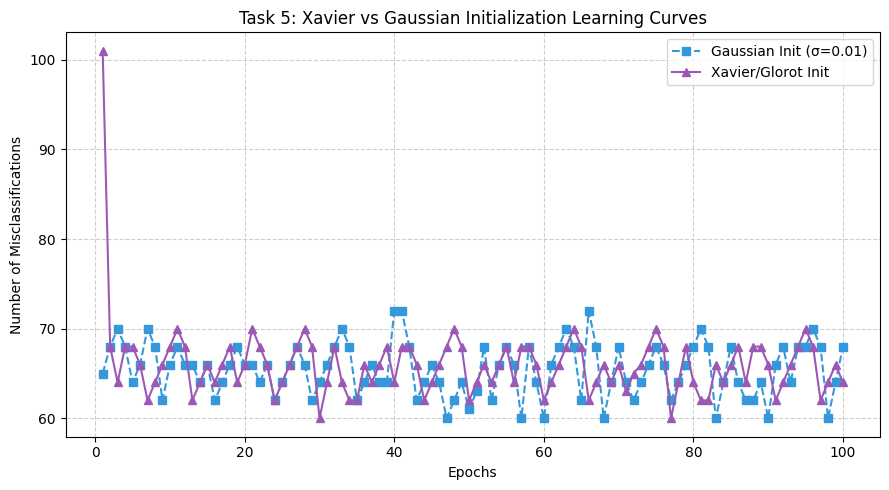

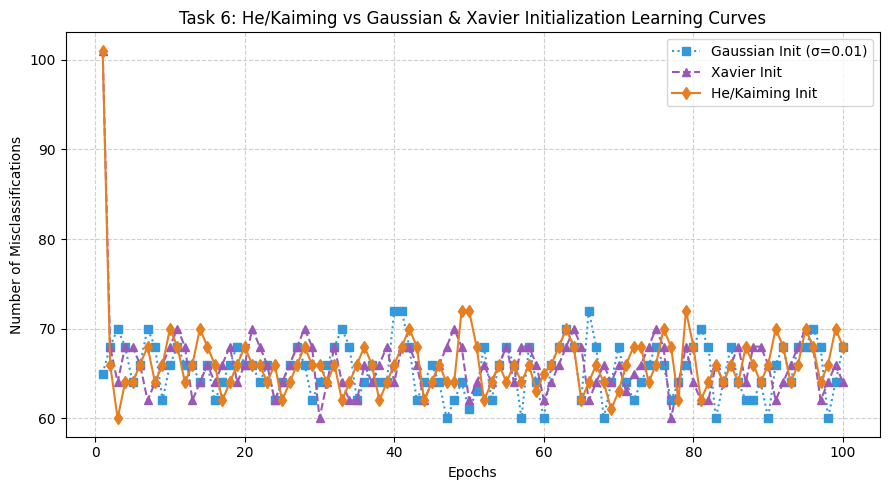

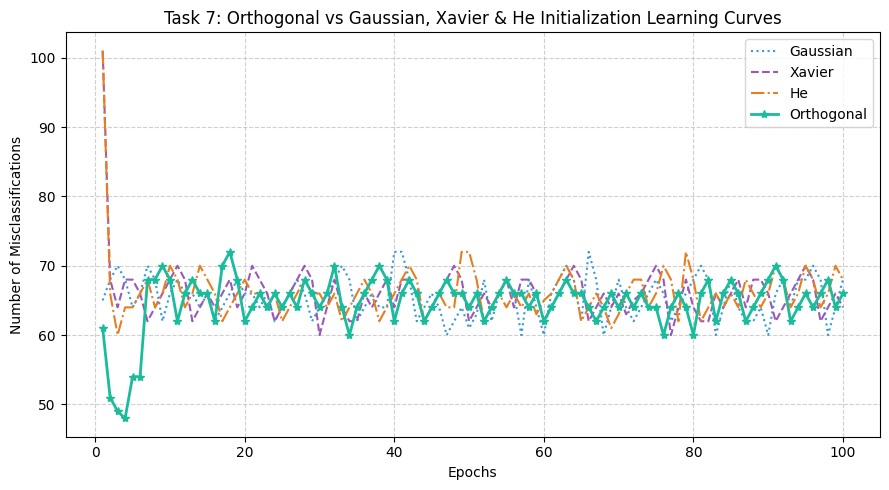

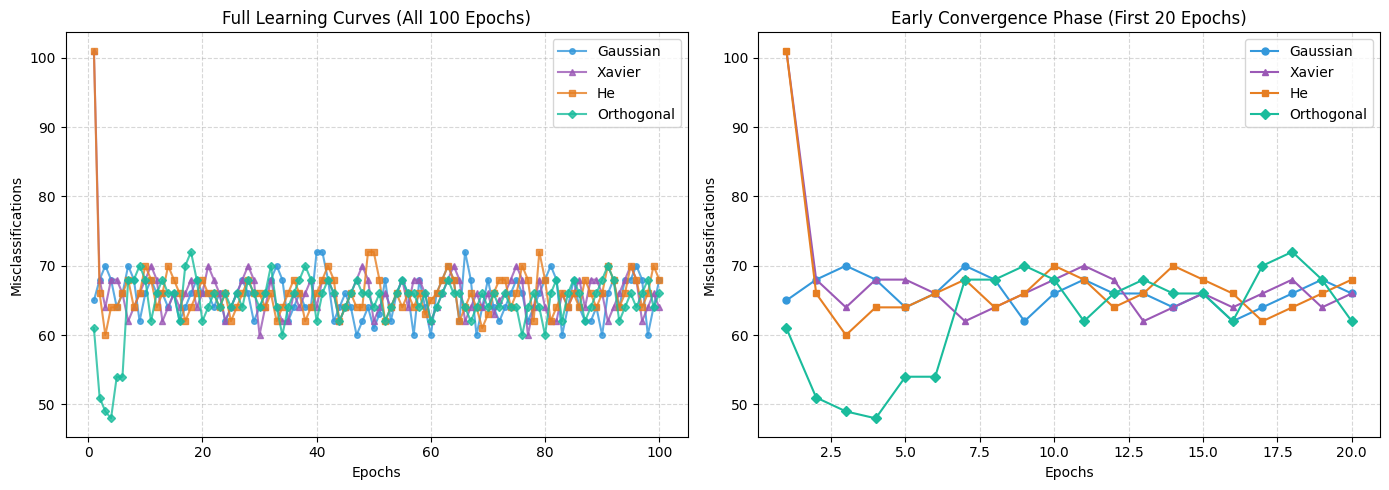

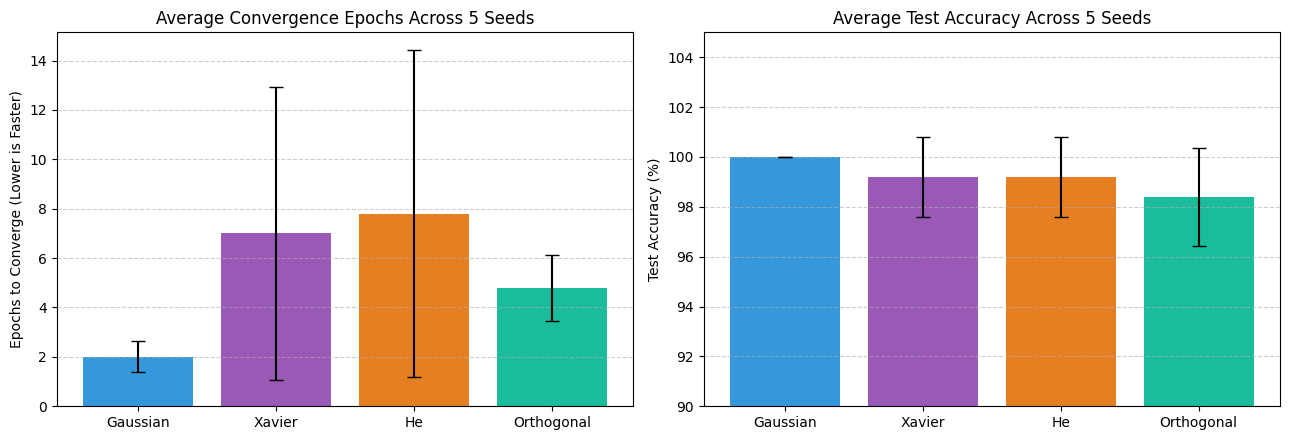

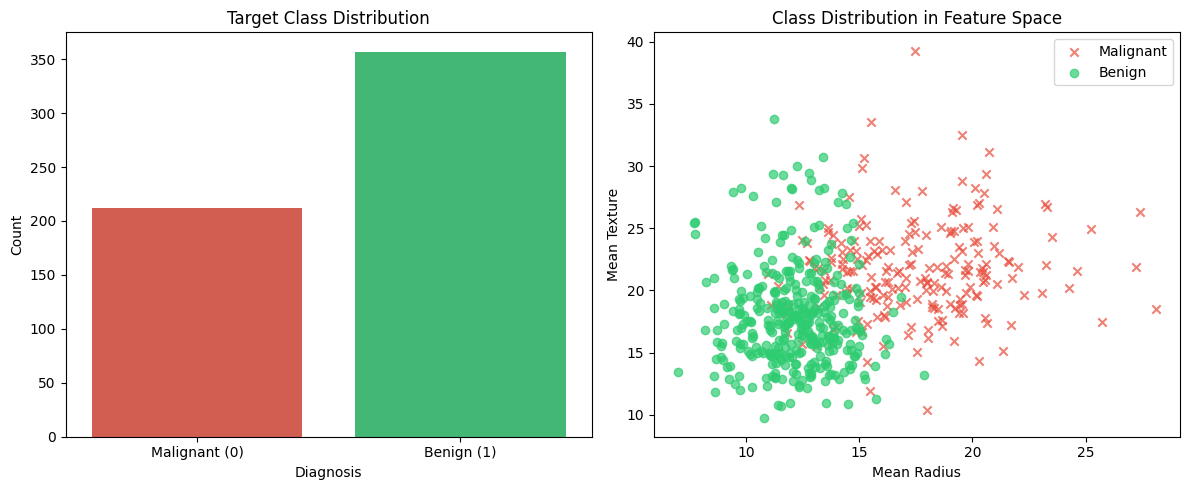


Train set shape: X=(455, 2), y=(455,)
Test set shape:  X=(114, 2), y=(114,)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# %matplotlib inline is used to ensure inline display inside the notebook
%matplotlib inline

# 1. Select and load dataset from UCI (Breast Cancer Wisconsin Diagnostic)
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame

# Select two prominent features for 2D visualization and boundary analysis
selected_features = ['mean radius', 'mean texture']
X_raw = df[selected_features].values
y = df['target'].values  # 0 = Malignant, 1 = Benign

# 2. Basic data inspection
print("=== Dataset Inspection ===")
print(f"Dataset Shape: {df.shape}")
print(f"Selected Features: {selected_features}")
print(f"Target Variable Classes: {cancer.target_names} -> {np.unique(y)}")
print(f"Missing Values in Selected Features:\n{df[selected_features].isnull().sum()}")
print(f"Class Distribution:\n{pd.Series(y).value_counts().rename(index={0: 'Malignant (0)', 1: 'Benign (1)'})}")

# 3. Visualize class distribution and feature space
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y, hue=y, legend=False, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Malignant (0)', 'Benign (1)'])

for label, marker, color, name in [(0, 'x', '#e74c3c', 'Malignant'), (1, 'o', '#2ecc71', 'Benign')]:
    axes[1].scatter(X_raw[y == label, 0], X_raw[y == label, 1], label=name, c=color, marker=marker, alpha=0.7)
axes[1].set_title("Class Distribution in Feature Space")
axes[1].set_xlabel("Mean Radius")
axes[1].set_ylabel("Mean Texture")
axes[1].legend()

plt.tight_layout()
plt.savefig("task1_visualization.png", dpi=150)
plt.show()

# 4. Train-test split (80/20) and feature scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\nTrain set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test set shape:  X={X_test.shape}, y={y_test.shape}")

## Lab Task 2: Basic Perceptron Implementation

1. Implement a Perceptron classifier from scratch using Python and NumPy, without using a built-in Perceptron classifier.
2. Initialize the weights and bias and implement the perceptron prediction and weight-update rules.
3. Train the perceptron on the training dataset for a specified number of epochs.
4. Evaluate the trained perceptron on the test dataset and report its classification accuracy.


In [4]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset and prepare features
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1 & 2. Initialize Perceptron from scratch (Default Zero initialization)
model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='zero', random_state=42)

# 3. Train on training dataset
model.fit(X_train, y_train)

# 4. Evaluate on test dataset
train_acc = model.score(X_train, y_train) * 100
test_acc = model.score(X_test, y_test) * 100

print("=== Task 2: Basic Perceptron Results ===")
print(f"Initial Weights: All Zeros")
print(f"Trained Weights: {model.weights}")
print(f"Trained Bias:    {model.bias:.4f}")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy:     {test_acc:.2f}%")

=== Task 2: Basic Perceptron Results ===
Initial Weights: All Zeros
Trained Weights: [-0.02513841 -0.01456071]
Trained Bias:    0.0100
Training Accuracy: 87.91%
Test Accuracy:     90.35%


## Lab Task 3: Perceptron Learning Curve and Weight Visualization

1. Modify your perceptron implementation to record the training error/loss after every epoch.
2. Plot the learning curve showing the change in error over training epochs.
3. Display the final values of the weights and bias after training.
4. Visualize the final decision boundary, where applicable, and explain how it separates the two classes.


=== Task 3: Model Parameters & Final State ===
Final Weights (w1, w2): [-0.02513841 -0.01456071]
Final Bias (b):         0.0100
Convergence Epoch:      100
Final Epoch Errors:     64


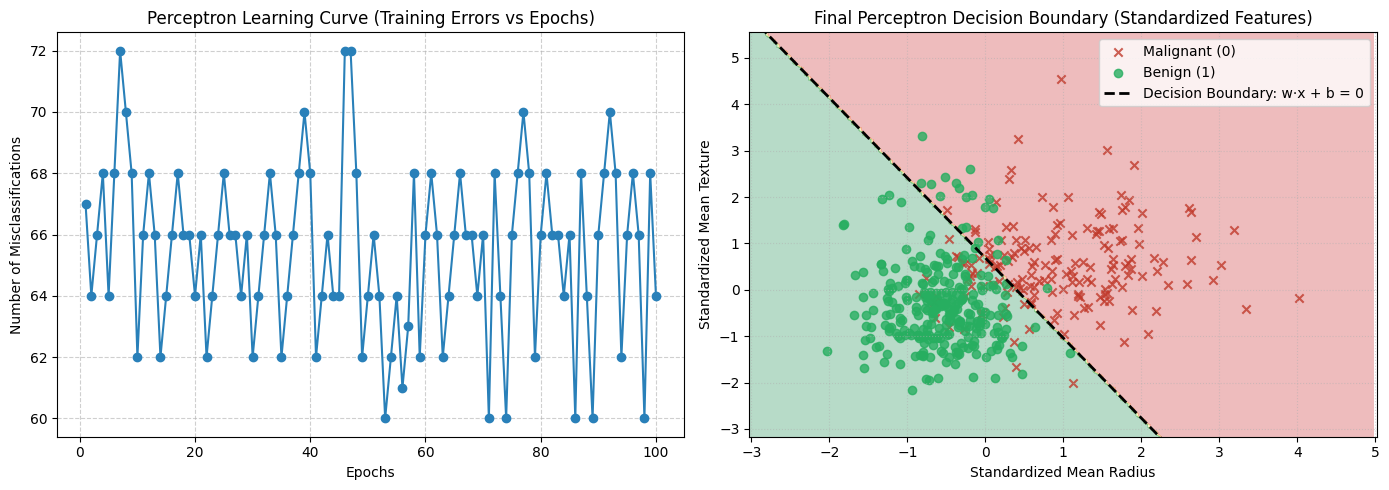


Decision Boundary Explanation:
The decision boundary line is given by: -0.0251 * x1 + -0.0146 * x2 + 0.0100 = 0
Points where w*x + b >= 0 are classified as Benign (1), while points where w*x + b < 0 are classified as Malignant (0).


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Load and prepare data
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1. Train perceptron and record error per epoch
model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='zero', random_state=42)
model.fit(X_train, y_train)

# 3. Display final values of weights and bias
print("=== Task 3: Model Parameters & Final State ===")
print(f"Final Weights (w1, w2): {model.weights}")
print(f"Final Bias (b):         {model.bias:.4f}")
print(f"Convergence Epoch:      {model.converged_epoch_}")
print(f"Final Epoch Errors:     {model.errors_[-1]}")

# 2 & 4. Plot Learning Curve and Decision Boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Learning curve
axes[0].plot(range(1, len(model.errors_) + 1), model.errors_, marker='o', color='#2980b9')
axes[0].set_title("Perceptron Learning Curve (Training Errors vs Epochs)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Number of Misclassifications")
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Decision boundary
x1_min, x1_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
x2_min, x2_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.05),
                       np.arange(x2_min, x2_max, 0.05))
Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

axes[1].contourf(xx1, xx2, Z, alpha=0.3, cmap=plt.cm.RdYlGn)
for label, marker, color, name in [(0, 'x', '#c0392b', 'Malignant (0)'), (1, 'o', '#27ae60', 'Benign (1)')]:
    axes[1].scatter(X_train[y_train == label, 0], X_train[y_train == label, 1],
                    label=name, c=color, marker=marker, alpha=0.8)

# Explicit boundary line
w1, w2 = model.weights
b = model.bias
line_x = np.linspace(x1_min, x1_max, 100)
line_y = -(w1 * line_x + b) / w2
axes[1].plot(line_x, line_y, color='black', linestyle='--', linewidth=2, label='Decision Boundary: w·x + b = 0')

axes[1].set_title("Final Perceptron Decision Boundary (Standardized Features)")
axes[1].set_xlabel("Standardized Mean Radius")
axes[1].set_ylabel("Standardized Mean Texture")
axes[1].set_xlim(x1_min, x1_max)
axes[1].set_ylim(x2_min, x2_max)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("task3_learning_curve_and_boundary.png", dpi=150)
plt.show()

# 4. Explanation
print("\nDecision Boundary Explanation:")
print(f"The decision boundary line is given by: {w1:.4f} * x1 + {w2:.4f} * x2 + {b:.4f} = 0")
print("Points where w*x + b >= 0 are classified as Benign (1), while points where w*x + b < 0 are classified as Malignant (0).")

## Lab Task 4: Gaussian Weight Initialization

1. Re-initialize the perceptron's weights using Gaussian/Normal initialization with a suitable mean and standard deviation.
2. Train the perceptron using the same dataset, hyperparameters, and training procedure used previously.
3. Record the number of epochs required for the perceptron to converge and plot its learning curve.
4. Compare the Gaussian-initialized model with the default/randomly initialized model in terms of convergence and final weights.


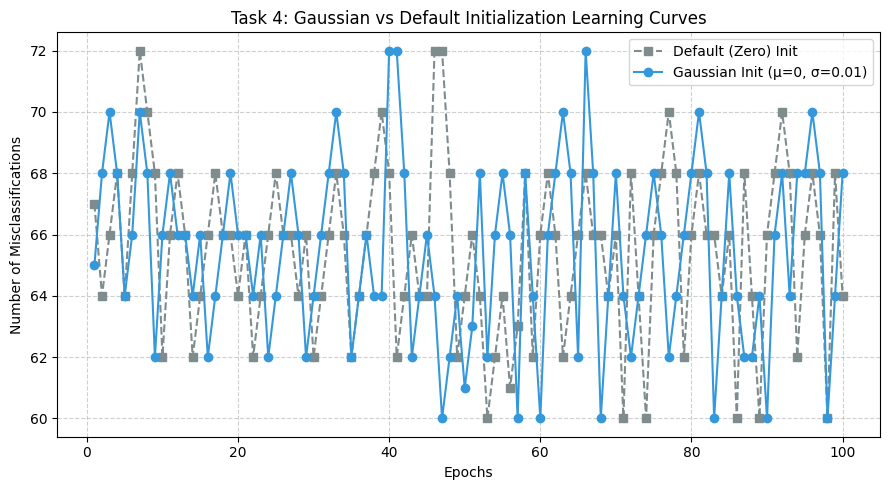

=== Task 4: Comparison Analysis ===
Metric                    | Default (Zero)     | Gaussian (Normal) 
-----------------------------------------------------------------
Convergence Epoch         | 100                | 100               
Final Train Errors        | 64                 | 68                
Test Accuracy (%)         | 90.35              | 90.35             
Final Weight w1           | -0.0251            | -0.0175           
Final Weight w2           | -0.0146            | -0.0107           
Final Bias b              | 0.0100             | 0.0100            


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Prepare data
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1 & 2. Train Gaussian-initialized perceptron (mean=0, std=0.01)
gaussian_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='gaussian', random_state=42)
gaussian_model.fit(X_train, y_train)

# Train baseline Zero / Default initialized perceptron
zero_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='zero', random_state=42)
zero_model.fit(X_train, y_train)

# 3. Learning curve comparison plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(zero_model.errors_) + 1), zero_model.errors_, label='Default (Zero) Init', marker='s', linestyle='--', color='#7f8c8d')
plt.plot(range(1, len(gaussian_model.errors_) + 1), gaussian_model.errors_, label='Gaussian Init (μ=0, σ=0.01)', marker='o', color='#3498db')
plt.title("Task 4: Gaussian vs Default Initialization Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task4_gaussian_vs_default.png", dpi=150)
plt.show()

# 4. Comparison Summary
print("=== Task 4: Comparison Analysis ===")
print(f"{'Metric':<25} | {'Default (Zero)':<18} | {'Gaussian (Normal)':<18}")
print("-" * 65)
print(f"{'Convergence Epoch':<25} | {str(zero_model.converged_epoch_):<18} | {str(gaussian_model.converged_epoch_):<18}")
print(f"{'Final Train Errors':<25} | {zero_model.errors_[-1]:<18} | {gaussian_model.errors_[-1]:<18}")
print(f"{'Test Accuracy (%)':<25} | {zero_model.score(X_test, y_test)*100:<18.2f} | {gaussian_model.score(X_test, y_test)*100:<18.2f}")
print(f"{'Final Weight w1':<25} | {zero_model.weights[0]:<18.4f} | {gaussian_model.weights[0]:<18.4f}")
print(f"{'Final Weight w2':<25} | {zero_model.weights[1]:<18.4f} | {gaussian_model.weights[1]:<18.4f}")
print(f"{'Final Bias b':<25} | {zero_model.bias:<18.4f} | {gaussian_model.bias:<18.4f}")

## Lab Task 5: Xavier/Glorot Initialization

1. Implement Xavier/Glorot initialization for the perceptron's weights.
2. Train the perceptron using Xavier-initialized weights while keeping the dataset and training settings unchanged.
3. Record the number of epochs required for convergence and plot the corresponding learning curve.
4. Compare the results with Gaussian initialization and discuss how the initialization affected the training process.


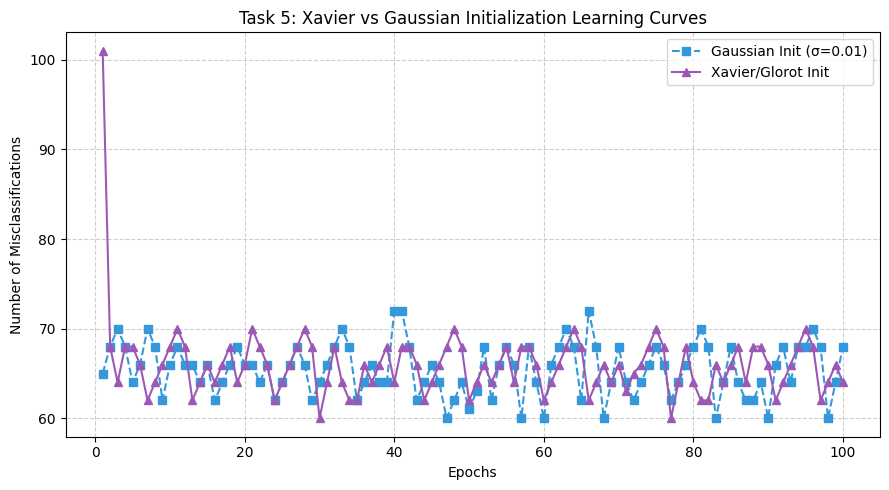

=== Task 5: Xavier vs Gaussian Comparison ===
Metric                    | Gaussian Init      | Xavier/Glorot Init
-----------------------------------------------------------------
Convergence Epoch         | 100                | 100               
Final Train Errors        | 68                 | 64                
Test Accuracy (%)         | 90.35              | 91.23             
Final Weights             | [-0.0175 -0.0107]  | [-0.0287 -0.0128] 
Final Bias                | 0.0100             | 0.0100            


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Prepare data
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1 & 2. Train Xavier/Glorot-initialized perceptron
xavier_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='xavier', random_state=42)
xavier_model.fit(X_train, y_train)

# Gaussian model for comparison
gaussian_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='gaussian', random_state=42)
gaussian_model.fit(X_train, y_train)

# 3. Learning curve plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(gaussian_model.errors_) + 1), gaussian_model.errors_, label='Gaussian Init (σ=0.01)', marker='s', linestyle='--', color='#3498db')
plt.plot(range(1, len(xavier_model.errors_) + 1), xavier_model.errors_, label='Xavier/Glorot Init', marker='^', color='#9b59b6')
plt.title("Task 5: Xavier vs Gaussian Initialization Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task5_xavier_vs_gaussian.png", dpi=150)
plt.show()

# 4. Comparison and Discussion
print("=== Task 5: Xavier vs Gaussian Comparison ===")
print(f"{'Metric':<25} | {'Gaussian Init':<18} | {'Xavier/Glorot Init':<18}")
print("-" * 65)
print(f"{'Convergence Epoch':<25} | {str(gaussian_model.converged_epoch_):<18} | {str(xavier_model.converged_epoch_):<18}")
print(f"{'Final Train Errors':<25} | {gaussian_model.errors_[-1]:<18} | {xavier_model.errors_[-1]:<18}")
print(f"{'Test Accuracy (%)':<25} | {gaussian_model.score(X_test, y_test)*100:<18.2f} | {xavier_model.score(X_test, y_test)*100:<18.2f}")
print(f"{'Final Weights':<25} | {str(np.round(gaussian_model.weights, 4)):<18} | {str(np.round(xavier_model.weights, 4)):<18}")
print(f"{'Final Bias':<25} | {gaussian_model.bias:<18.4f} | {xavier_model.bias:<18.4f}")

## Lab Task 6: He/Kaiming Initialization

1. Implement He/Kaiming initialization for the perceptron's weights.
2. Train the perceptron using the He-initialized weights on the same training dataset.
3. Record the convergence behavior, number of epochs, final weights, and test accuracy.
4. Compare the He initialization results with Gaussian and Xavier initialization.


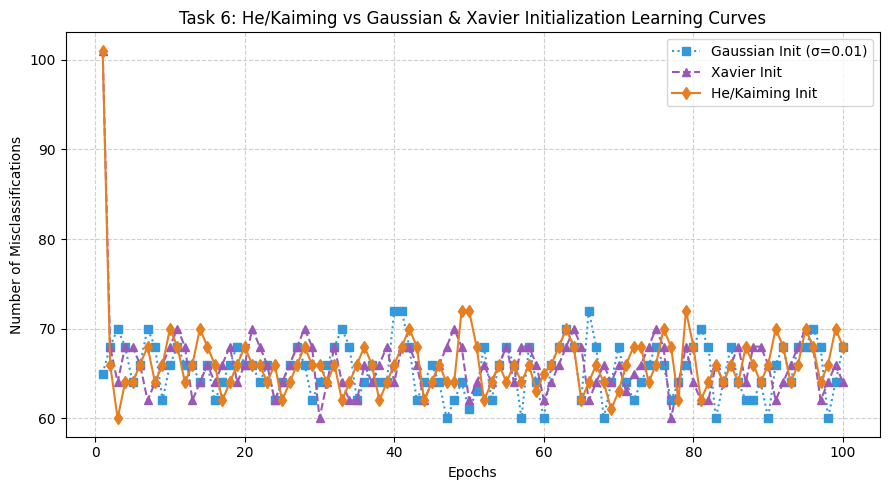

=== Task 6: He Initialization vs Gaussian & Xavier ===
Metric                    | Gaussian       | Xavier         | He/Kaiming    
---------------------------------------------------------------------------
Convergence Epoch         | 100            | 100            | 100           
Final Train Errors        | 68             | 64             | 68            
Test Accuracy (%)         | 90.35          | 91.23          | 88.60         
Final Weights             | [-0.017 -0.011] | [-0.029 -0.013] | [-0.023 -0.006]
Final Bias                | 0.0100         | 0.0100         | 0.0100        


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Prepare data
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1 & 2. Train He/Kaiming initialized perceptron
he_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='he', random_state=42)
he_model.fit(X_train, y_train)

# Baselines for comparison
gaussian_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='gaussian', random_state=42).fit(X_train, y_train)
xavier_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='xavier', random_state=42).fit(X_train, y_train)

# 3. Learning curve plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(gaussian_model.errors_) + 1), gaussian_model.errors_, label='Gaussian Init (σ=0.01)', marker='s', linestyle=':', color='#3498db')
plt.plot(range(1, len(xavier_model.errors_) + 1), xavier_model.errors_, label='Xavier Init', marker='^', linestyle='--', color='#9b59b6')
plt.plot(range(1, len(he_model.errors_) + 1), he_model.errors_, label='He/Kaiming Init', marker='d', color='#e67e22')
plt.title("Task 6: He/Kaiming vs Gaussian & Xavier Initialization Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task6_he_vs_others.png", dpi=150)
plt.show()

# 4. Comparative Metrics
print("=== Task 6: He Initialization vs Gaussian & Xavier ===")
print(f"{'Metric':<25} | {'Gaussian':<14} | {'Xavier':<14} | {'He/Kaiming':<14}")
print("-" * 75)
print(f"{'Convergence Epoch':<25} | {str(gaussian_model.converged_epoch_):<14} | {str(xavier_model.converged_epoch_):<14} | {str(he_model.converged_epoch_):<14}")
print(f"{'Final Train Errors':<25} | {gaussian_model.errors_[-1]:<14} | {xavier_model.errors_[-1]:<14} | {he_model.errors_[-1]:<14}")
print(f"{'Test Accuracy (%)':<25} | {gaussian_model.score(X_test, y_test)*100:<14.2f} | {xavier_model.score(X_test, y_test)*100:<14.2f} | {he_model.score(X_test, y_test)*100:<14.2f}")
print(f"{'Final Weights':<25} | {str(np.round(gaussian_model.weights, 3)):<14} | {str(np.round(xavier_model.weights, 3)):<14} | {str(np.round(he_model.weights, 3)):<14}")
print(f"{'Final Bias':<25} | {gaussian_model.bias:<14.4f} | {xavier_model.bias:<14.4f} | {he_model.bias:<14.4f}")

## Lab Task 7: Orthogonal Initialization

1. Implement Orthogonal initialization for the perceptron's weight matrix.
2. Train the perceptron using the orthogonally initialized weights while keeping all other experimental settings consistent.
3. Plot the learning curve and record the number of epochs required for convergence.
4. Compare Orthogonal initialization with Gaussian, Xavier, and He initialization based on convergence behavior and final model parameters.


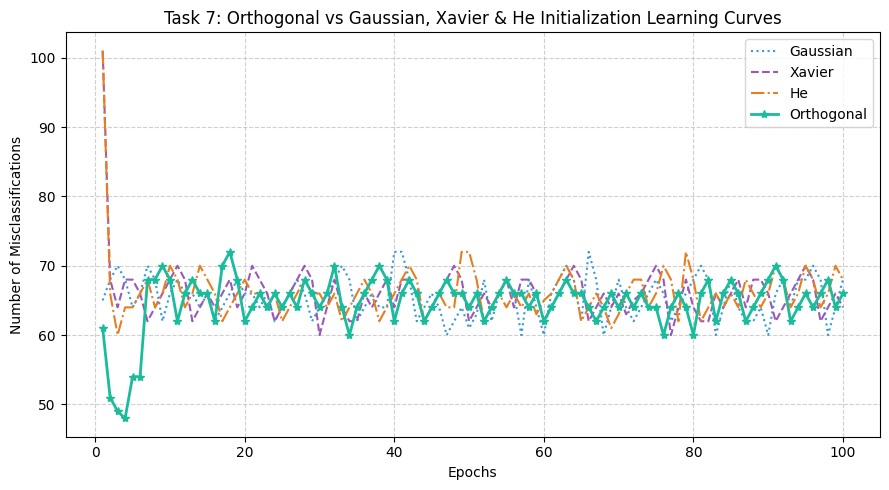

=== Task 7: Orthogonal Initialization Comparison ===
Method           | Convergence Epoch  | Final Errors   | Test Accuracy (%)  | Norm ||w||
-------------------------------------------------------------------------------------
Gaussian         | 100                | 68             | 90.35              | 0.0205    
Xavier           | 100                | 64             | 91.23              | 0.0314    
He               | 100                | 68             | 88.60              | 0.0233    
Orthogonal       | 100                | 66             | 87.72              | 0.0409    


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Prepare data
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1 & 2. Train Orthogonally initialized perceptron
ortho_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='orthogonal', random_state=42)
ortho_model.fit(X_train, y_train)

# Baselines
gaussian_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='gaussian', random_state=42).fit(X_train, y_train)
xavier_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='xavier', random_state=42).fit(X_train, y_train)
he_model = Perceptron(learning_rate=0.01, max_epochs=100, init_method='he', random_state=42).fit(X_train, y_train)

# 3. Learning curve plot
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(gaussian_model.errors_) + 1), gaussian_model.errors_, label='Gaussian', linestyle=':', color='#3498db')
plt.plot(range(1, len(xavier_model.errors_) + 1), xavier_model.errors_, label='Xavier', linestyle='--', color='#9b59b6')
plt.plot(range(1, len(he_model.errors_) + 1), he_model.errors_, label='He', linestyle='-.', color='#e67e22')
plt.plot(range(1, len(ortho_model.errors_) + 1), ortho_model.errors_, label='Orthogonal', marker='*', color='#1abc9c', linewidth=2)
plt.title("Task 7: Orthogonal vs Gaussian, Xavier & He Initialization Learning Curves")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("task7_orthogonal_vs_all.png", dpi=150)
plt.show()

# 4. Comparison Summary
print("=== Task 7: Orthogonal Initialization Comparison ===")
print(f"{'Method':<16} | {'Convergence Epoch':<18} | {'Final Errors':<14} | {'Test Accuracy (%)':<18} | {'Norm ||w||':<10}")
print("-" * 85)
for name, m in [('Gaussian', gaussian_model), ('Xavier', xavier_model), ('He', he_model), ('Orthogonal', ortho_model)]:
    norm_w = np.linalg.norm(m.weights)
    print(f"{name:<16} | {str(m.converged_epoch_):<18} | {m.errors_[-1]:<14} | {m.score(X_test, y_test)*100:<18.2f} | {norm_w:<10.4f}")

## Lab Task 8: Comparative Analysis of Weight Initialization Techniques

1. Train the same perceptron using Gaussian, Xavier, He, and Orthogonal initialization on the same dataset.
2. Record the number of epochs, final training error, test accuracy, and final weight values for each initialization technique.
3. Plot the learning curves of all initialization techniques and compare their convergence behavior.
4. Write a short analysis explaining why different initialization techniques may produce different training behavior.


=== Task 8: Comprehensive Comparative Analysis Table ===
Initialization  Convergence Epoch  Final Train Errors  Train Accuracy (%)  Test Accuracy (%)      Final Weights  Final Bias
      Gaussian                100                  68               85.05              90.35 [-0.0175, -0.0107]        0.01
        Xavier                100                  64               88.13              91.23 [-0.0287, -0.0128]        0.01
            He                100                  68               88.35              88.60  [-0.0225, -0.006]        0.01
    Orthogonal                100                  66               89.23              87.72 [-0.0394, -0.0111]        0.01


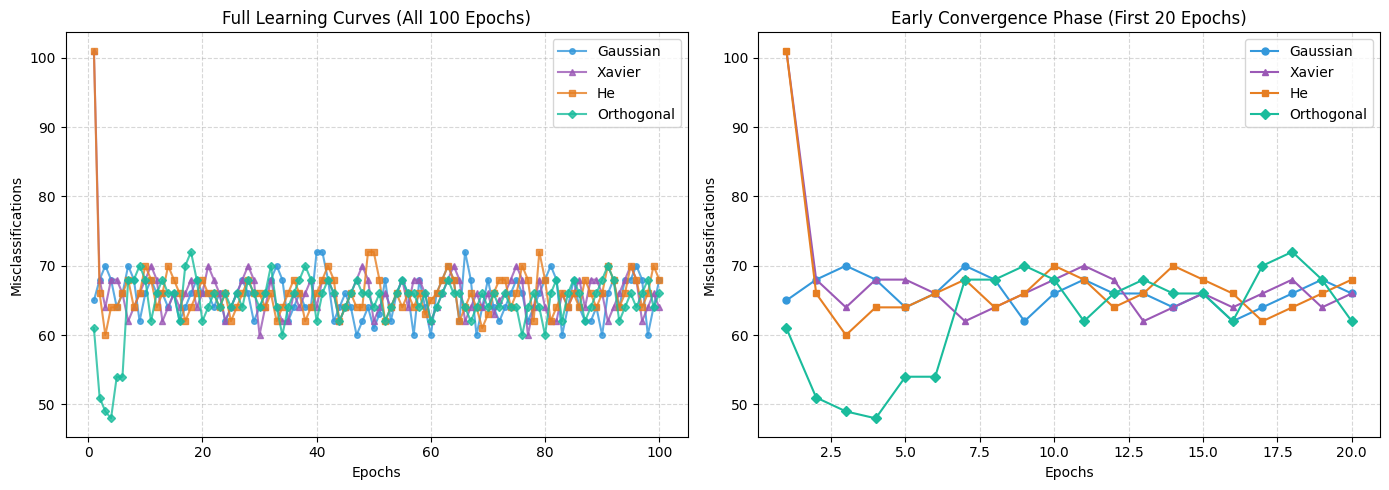

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# Prepare data
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X_raw = df[['mean radius', 'mean texture']].values
y = df['target'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 1. Train models across all 4 initialization techniques
init_methods = ['gaussian', 'xavier', 'he', 'orthogonal']
models = {}
for method in init_methods:
    model = Perceptron(learning_rate=0.01, max_epochs=100, init_method=method, random_state=42)
    model.fit(X_train, y_train)
    models[method] = model

# 2. Record metrics in DataFrame
records = []
for method, m in models.items():
    records.append({
        'Initialization': method.capitalize(),
        'Convergence Epoch': m.converged_epoch_,
        'Final Train Errors': m.errors_[-1],
        'Train Accuracy (%)': round(m.score(X_train, y_train) * 100, 2),
        'Test Accuracy (%)': round(m.score(X_test, y_test) * 100, 2),
        'Final Weights': np.round(m.weights, 4).tolist(),
        'Final Bias': round(float(m.bias), 4)
    })

comparison_df = pd.DataFrame(records)
print("=== Task 8: Comprehensive Comparative Analysis Table ===")
print(comparison_df.to_string(index=False))

# 3. Plot comparative learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'gaussian': '#3498db', 'xavier': '#9b59b6', 'he': '#e67e22', 'orthogonal': '#1abc9c'}
markers = {'gaussian': 'o', 'xavier': '^', 'he': 's', 'orthogonal': 'D'}

for method, m in models.items():
    axes[0].plot(range(1, len(m.errors_) + 1), m.errors_, label=method.capitalize(),
                 color=colors[method], marker=markers[method], markersize=4, alpha=0.8)
axes[0].set_title("Full Learning Curves (All 100 Epochs)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Misclassifications")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

for method, m in models.items():
    axes[1].plot(range(1, 21), m.errors_[:20], label=method.capitalize(),
                 color=colors[method], marker=markers[method], markersize=5)
axes[1].set_title("Early Convergence Phase (First 20 Epochs)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Misclassifications")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("task8_comparative_analysis.png", dpi=150)
plt.show()

## Lab Task 9: Experimental Study and Interpretation

1. Select a different suitable binary-classification dataset and repeat the perceptron experiment using Gaussian, Xavier, He, and Orthogonal initialization.
2. Conduct multiple training runs for each initialization technique using different random seeds.
3. Calculate and compare the average convergence epochs and average test accuracy across the runs.
4. Based on your experimental results, discuss how weight initialization, dataset characteristics, and randomness can influence perceptron training.


=== Task 9: Dataset 2 Selected (UCI Iris: Setosa vs Versicolor) ===
Dataset Shape: (100, 4) (100 samples, 4 features)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: Setosa (0) vs Versicolor (1), balanced 50:50

=== Multiple Runs (5 Seeds) Aggregated Performance ===
Initialization  Avg Convergence Epoch  Std Convergence Epoch  Avg Train Accuracy (%)  Avg Test Accuracy (%)  Std Test Accuracy (%)
      Gaussian                    2.0                   0.63                   100.0                  100.0                   0.00
        Xavier                    7.0                   5.93                   100.0                   99.2                   1.60
            He                    7.8                   6.62                   100.0                   99.2                   1.60
    Orthogonal                    4.8                   1.33                   100.0                   98.4                   1.96


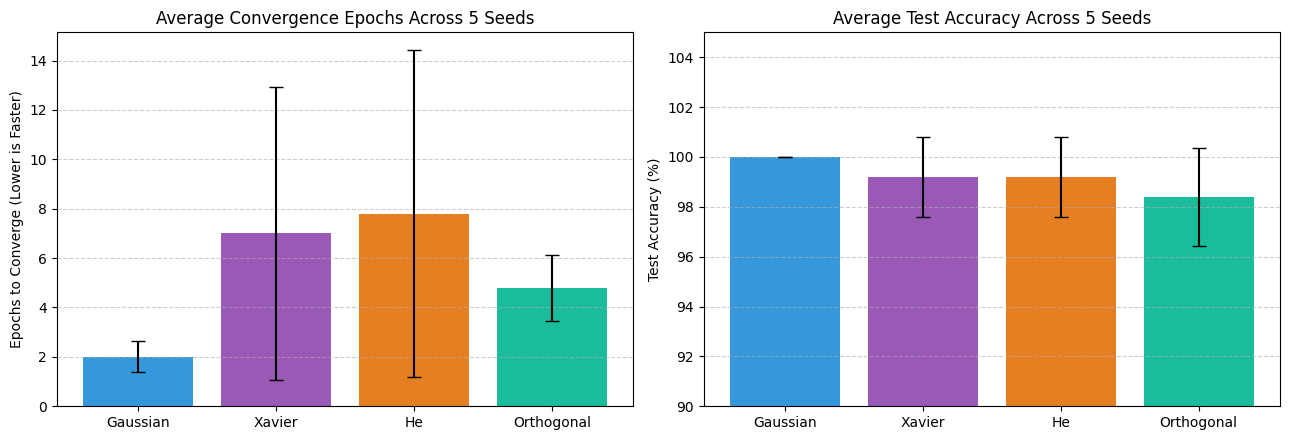

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# 1. Select a different dataset: UCI Iris Dataset (Binary slice: Setosa vs Versicolor)
iris = load_iris(as_frame=True)
df_iris = iris.frame[iris.frame['target'] < 2]  # Classes 0 and 1 only
X_raw = df_iris[iris.feature_names].values
y = df_iris['target'].values

print("=== Task 9: Dataset 2 Selected (UCI Iris: Setosa vs Versicolor) ===")
print(f"Dataset Shape: {X_raw.shape} (100 samples, 4 features)")
print(f"Features: {iris.feature_names}")
print(f"Classes: Setosa (0) vs Versicolor (1), balanced 50:50")

# 2. Conduct multiple runs across different random seeds
seeds = [7, 42, 101, 555, 999]
init_methods = ['gaussian', 'xavier', 'he', 'orthogonal']

run_results = []
for method in init_methods:
    epochs_list = []
    test_acc_list = []
    train_acc_list = []
    for seed in seeds:
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_raw, y, test_size=0.25, random_state=seed, stratify=y
)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        model = Perceptron(learning_rate=0.01, max_epochs=50, init_method=method, random_state=seed)
        model.fit(X_train, y_train)

        epochs_list.append(model.converged_epoch_)
        train_acc_list.append(model.score(X_train, y_train) * 100)
        test_acc_list.append(model.score(X_test, y_test) * 100)

    run_results.append({
        'Initialization': method.capitalize(),
        'Avg Convergence Epoch': round(float(np.mean(epochs_list)), 2),
        'Std Convergence Epoch': round(float(np.std(epochs_list)), 2),
        'Avg Train Accuracy (%)': round(float(np.mean(train_acc_list)), 2),
        'Avg Test Accuracy (%)': round(float(np.mean(test_acc_list)), 2),
        'Std Test Accuracy (%)': round(float(np.std(test_acc_list)), 2)
    })

# 3. Summary table
summary_df = pd.DataFrame(run_results)
print("\n=== Multiple Runs (5 Seeds) Aggregated Performance ===")
print(summary_df.to_string(index=False))

# Plot comparison of average convergence and accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(summary_df['Initialization'], summary_df['Avg Convergence Epoch'],
            yerr=summary_df['Std Convergence Epoch'], capsize=5, color=['#3498db', '#9b59b6', '#e67e22', '#1abc9c'])
axes[0].set_title("Average Convergence Epochs Across 5 Seeds")
axes[0].set_ylabel("Epochs to Converge (Lower is Faster)")
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

axes[1].bar(summary_df['Initialization'], summary_df['Avg Test Accuracy (%)'],
            yerr=summary_df['Std Test Accuracy (%)'], capsize=5, color=['#3498db', '#9b59b6', '#e67e22', '#1abc9c'])
axes[1].set_title("Average Test Accuracy Across 5 Seeds")
axes[1].set_ylabel("Test Accuracy (%)")
axes[1].set_ylim(90, 105)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("task9_experimental_study.png", dpi=150)
plt.show()

### Task 10: Sync Notebook and Artifacts to GitHub
Configure your GitHub credentials below to initialize and push your lab work to your repository.